In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

In [3]:
df = pd.read_csv('../data/processed/lojas_unificadas_limpas.csv')

In [4]:
mapeamento_ufs = {
    'Acre': 'AC', 'Alagoas': 'AL', 'Amapá': 'AP', 'Amazonas': 'AM', 'Bahia': 'BA',
    'Ceará': 'CE', 'Distrito Federal': 'DF', 'Espírito Santo': 'ES', 'Goiás': 'GO',
    'Maranhão': 'MA', 'Mato Grosso': 'MT', 'Mato Grosso do Sul': 'MS', 'Minas Gerais': 'MG',
    'Pará': 'PA', 'Paraíba': 'PB', 'Paraná': 'PR', 'Pernambuco': 'PE', 'Piauí': 'PI',
    'Rio de Janeiro': 'RJ', 'Rio Grande do Norte': 'RN', 'Rio Grande do Sul': 'RS',
    'Rondônia': 'RO', 'Roraima': 'RR', 'Santa Catarina': 'SC', 'São Paulo': 'SP',
    'Sergipe': 'SE', 'Tocantins': 'TO'
}

In [5]:
df['estado'] = df['estado'].astype(str).str.strip()
df['estado'] = df['estado'].replace(mapeamento_ufs)

df['cidade'] = df['cidade'].astype(str).str.strip().str.upper()

print("Estados padronizados com sucesso!")
print(df['estado'].unique())

Estados padronizados com sucesso!
<StringArray>
[   'AC',    'AL',    'AM',    'BA',    'CE',    'DF',    'ES',    'GO',
    'MA',    'MT',    'MS',    'MG',    'PR',    'PB',    'PA',    'PE',
    'PI',    'RN',    'RS',    'RJ',    'RO',    'RR',    'SC',    'SE',
    'SP',    'TO',    'AP',    'MY',     nan, 'Amapa', 'Goias']
Length: 31, dtype: str


In [6]:
populacao_ibge = {
    'SP': 44411238, 'MG': 20538718, 'RJ': 16054147, 'BA': 14141626, 'PR': 11444380,
    'RS': 10882965, 'PE': 9059113, 'CE': 8794957, 'PA': 8121025, 'SC': 7610361,
    'GO': 7056495, 'MA': 6776152, 'AM': 3941613, 'ES': 3833712, 'PB': 3974687,
    'RN': 3302729, 'MT': 3658649, 'AL': 3127683, 'PI': 3272199, 'DF': 2817381,
    'MS': 2757013, 'SE': 2211868, 'RO': 1581196, 'TO': 1511460, 'AC': 830018,
    'AP': 733759, 'RR': 636707
}

df_pop = pd.DataFrame(list(populacao_ibge.items()), columns=['estado', 'populacao'])

In [7]:
contagem_estados = df.groupby('estado').size().reset_index(name='qtd_lojas')

In [8]:
df_cobertura = pd.merge(contagem_estados, df_pop, on='estado')

df_cobertura['lojas_por_100k'] = (df_cobertura['qtd_lojas'] / df_cobertura['populacao']) * 100000
df_cobertura = df_cobertura.sort_values(by='lojas_por_100k', ascending=False)

C:\Users\luizf\AppData\Local\Temp\ipykernel_41860\2686009787.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cobertura, x='estado', y='lojas_por_100k', palette='viridis')


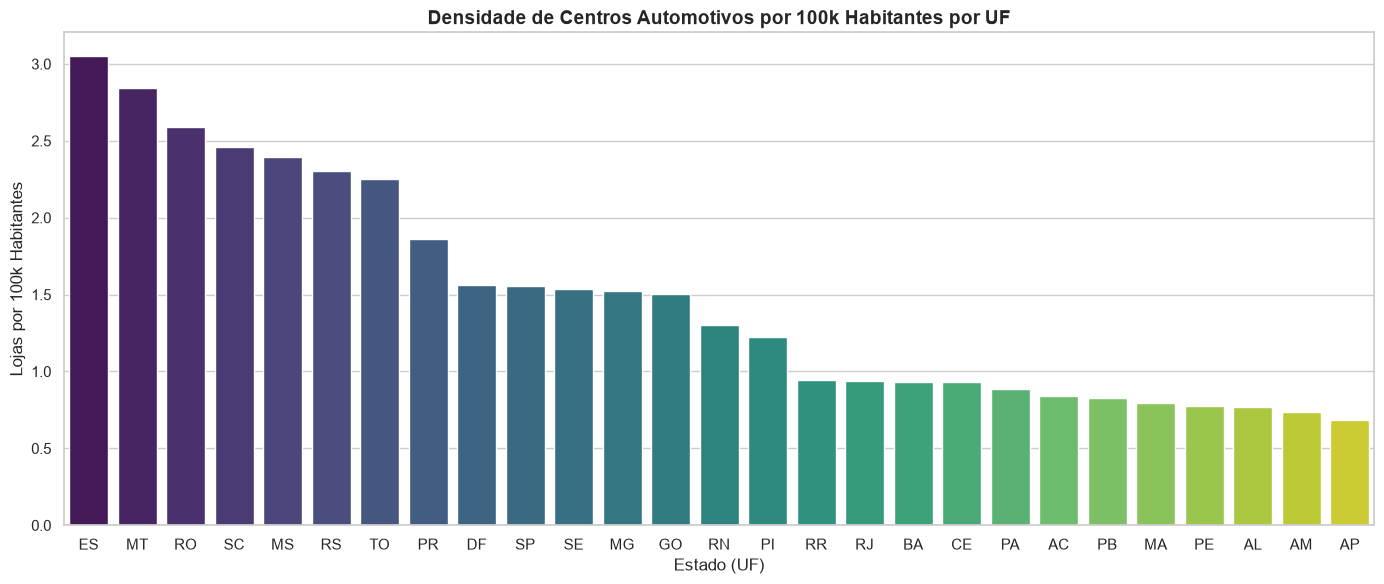

In [9]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_cobertura, x='estado', y='lojas_por_100k', palette='viridis')
plt.title('Densidade de Centros Automotivos por 100k Habitantes por UF', fontsize=14, fontweight='bold')
plt.xlabel('Estado (UF)', fontsize=12)
plt.ylabel('Lojas por 100k Habitantes', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
print("ESTADOS MAIS ADENSADOS (Saturação de Mercado):")
print(df_cobertura.head(5)[['estado', 'lojas_por_100k']].to_string(index=False))
print("\nESTADOS SUBATENDIDOS (Oportunidade de Expansão):")
print(df_cobertura.tail(5)[['estado', 'lojas_por_100k']].to_string(index=False))

ESTADOS MAIS ADENSADOS (Saturação de Mercado):
estado  lojas_por_100k
    ES        3.051872
    MT        2.842579
    RO        2.592974
    SC        2.457176
    MS        2.393895

ESTADOS SUBATENDIDOS (Oportunidade de Expansão):
estado  lojas_por_100k
    MA        0.796912
    PE        0.772703
    AL        0.767341
    AM        0.735739
    AP        0.681423


In [11]:
cidades_filtradas = df.groupby('cidade').size().reset_index(name='total_lojas_cidade')
cidades_filtradas = cidades_filtradas[cidades_filtradas['total_lojas_cidade'] > 10]

In [12]:
df_hhi_base = df[df['cidade'].isin(cidades_filtradas['cidade'])]

In [13]:
share_rede_cidade = df_hhi_base.groupby(['cidade', 'rede']).size().reset_index(name='qtd_rede')
share_rede_cidade = pd.merge(share_rede_cidade, cidades_filtradas, on='cidade')

In [14]:
share_rede_cidade['market_share'] = (share_rede_cidade['qtd_rede'] / share_rede_cidade['total_lojas_cidade']) * 100

share_rede_cidade['share_quadrado'] = share_rede_cidade['market_share'] ** 2
df_hhi_final = share_rede_cidade.groupby('cidade')['share_quadrado'].sum().reset_index(name='HHI')

In [15]:
df_hhi_final = pd.merge(df_hhi_final, cidades_filtradas, on='cidade').sort_values(by='HHI', ascending=False)

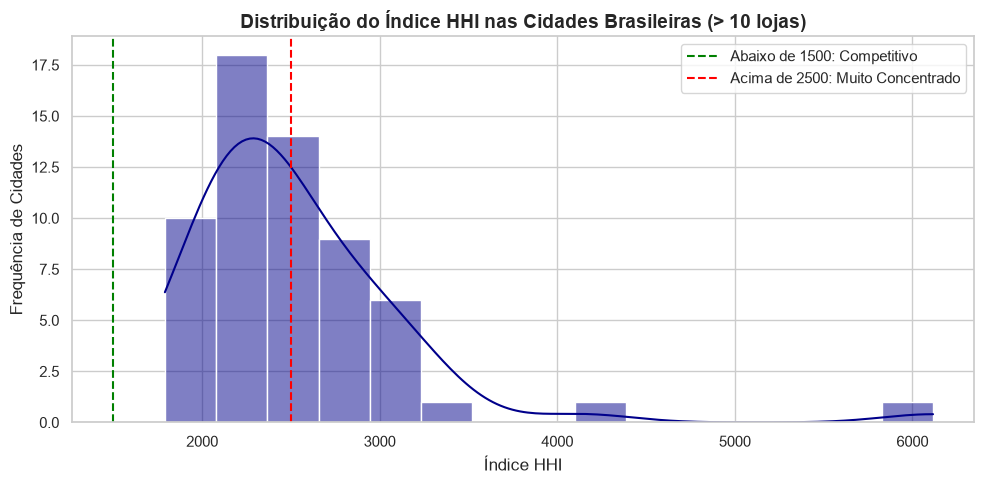

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df_hhi_final['HHI'], bins=15, kde=True, color='darkblue')
plt.axvline(1500, color='green', linestyle='--', label='Abaixo de 1500: Competitivo')
plt.axvline(2500, color='red', linestyle='--', label='Acima de 2500: Muito Concentrado')
plt.title('Distribuição do Índice HHI nas Cidades Brasileiras (> 10 lojas)', fontsize=14, fontweight='bold')
plt.xlabel('Índice HHI', fontsize=12)
plt.ylabel('Frequência de Cidades', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
print("TOP 10 CIDADES MAIS CONCENTRADAS (Monopólios/Oligopólios locais):")
print(df_hhi_final.head(10)[['cidade', 'total_lojas_cidade', 'HHI']].to_string(index=False))

TOP 10 CIDADES MAIS CONCENTRADAS (Monopólios/Oligopólios locais):
               cidade  total_lojas_cidade         HHI
              ARACAJU                  22 6115.702479
SAO JOSE DO RIO PRETO                  18 4135.802469
SAO BERNARDO DO CAMPO                  22 3305.785124
              MARINGA                  11 3223.140496
              UBERABA                  11 3223.140496
       RIBEIRAO PRETO                  16 3203.125000
          PORTO VELHO                  12 3194.444444
       RIO DE JANEIRO                  62 3069.719043
          SANTO ANDRE                  15 2977.777778
               GURUPI                  11 2892.561983


In [18]:
mapa_calor = folium.Map(location=[-15.7801, -47.9292], zoom_start=4, tiles='cartodbpositron')

In [19]:
coordenadas = df[['lat', 'lon']].dropna().values.tolist()

HeatMap(
    coordenadas,
    name='Densidade de Lojas',
    radius=15,
    blur=10,
    max_zoom=1
).add_to(mapa_calor)

caminho_mapa = '../notebooks/heatmap_densidade.html'
mapa_calor.save(caminho_mapa)
print(f"Mapa interativo salvo em: {caminho_mapa}")

Mapa interativo salvo em: ../notebooks/heatmap_densidade.html


In [20]:
mapa_calor